### Extract timing info from running MACHINA's pmh_ti on all m5 and m8 simulated data

In [1]:
import os
import pandas as pd
repo_dir = "/data/morrisq/divyak/projects/metient/metient"
metient_results_dir = '/data/morrisq/divyak/data/metient_prediction_results/'
mach_sim_dir = os.path.join(repo_dir, "test/machina_simulated_data")
mach_time_fn = os.path.join(mach_sim_dir, "pmh_ti_timing_8cores_11232022.txt")

DATE = "08072024"
PARAMS = "calibrate_wip_new_split"
CALIBRATE = True
PRIM_MET_SPLIT = True

MIG_TYPES = ["mS", "M", "S", "R"]
cols = ["seed", "site", "mig_type", "time"]

data = []
with open(mach_time_fn, "r") as f:
    for line in f:
        if "Runtime" in line:
            items = line.split()
            seed = int(items[3][:-1])
            mig_type = items[5][:-1]
            site = items[8][:-1]
            time = float(items[9])
            data.append([seed, site, mig_type, time])
machina_time_df = pd.DataFrame(data, columns=cols)
machina_time_df

,seed,site,mig_type,time
0,0,m5,mS,17.906445
1,10,m5,mS,11.254564
2,12,m5,mS,6.827857
3,2,m5,mS,7.802355
4,3,m5,mS,19.485894
...,...,...,...,...
74,383,m8,R,1311.944181
75,394,m8,R,257.018207
76,905,m8,R,266.204274
77,981,m8,R,805.483616


### Extract timing info from running Metient


In [2]:
import glob
import json

data = []
num_runs = 5
tot_sim_trees = 1647
batch_sizes = [64, 256, 1024]

for bs in batch_sizes:
    for run in range(1,num_runs+1):
        stat_fns = glob.glob(os.path.join(metient_results_dir,f'predictions_batch_exp_bs{bs}_{PARAMS}_r{run}_{DATE}','perf_stats*'))
        ct = 0
        print(bs, run, len(stat_fns))
        for stat_fn in stat_fns:
            with open(stat_fn, "r") as f:
                for line in f:
                    #print(line)
                    items = line.strip().split()
                    data.append([bs, items[0], items[1], int(items[2]), int(items[3]), float(items[5])])
                    ct += 1
        assert(ct==tot_sim_trees)

cols = ["batch_size", "site", "mig_type", "seed", "tree_num", "time_with_plotting"]
metient_df = pd.DataFrame(data, columns=cols)
# Group by 'Category' and apply the aggregation functions
agg_rules = {"time_with_plotting":"mean"}
metient_df = metient_df.groupby(["batch_size",'site', 'mig_type', 'seed', 'tree_num']).agg(agg_rules).reset_index()
metient_df

64 1 80
64 2 80
64 3 80
64 4 80
64 5 80
256 1 80
256 2 80
256 3 80
256 4 80
256 5 80
1024 1 80
1024 2 80
1024 3 80
1024 4 80
1024 5 80


,batch_size,site,mig_type,seed,tree_num,time_with_plotting
0,64,m5,M,76,0,2.359393
1,64,m5,M,76,1,1.948863
2,64,m5,M,76,2,2.114228
3,64,m5,M,76,3,1.954543
4,64,m5,M,209,0,6.469254
...,...,...,...,...,...,...
4936,1024,m8,mS,12,103,6.464327
4937,1024,m8,mS,12,104,7.005744
4938,1024,m8,mS,12,105,6.850740
4939,1024,m8,mS,12,106,6.060168


In [3]:
# Get number of trees per site/mig_type/seed combo
tree_nums_df = metient_df[metient_df["batch_size"]==64].groupby(['site', 'mig_type', 'seed']).size().reset_index(name='counts')
tree_nums_df

,site,mig_type,seed,counts
0,m5,M,76,4
1,m5,M,209,12
2,m5,M,473,80
3,m5,M,512,12
4,m5,M,534,24
...,...,...,...,...
75,m8,mS,7,2
76,m8,mS,8,2
77,m8,mS,9,1
78,m8,mS,10,4


### If timing calibrate mode, need to add the extra time needed for calibration and reordering/saving trees

In [4]:

def add_cal_time(row, bs_to_mig_type_to_avg_cal_time):
    cal_time = bs_to_mig_type_to_avg_cal_time[row['batch_size']][row['mig_type']]
    return row['time_with_plotting'] + cal_time
    
if CALIBRATE:
    # Load times needed for each category
    TYPES = ['prim_only', 'met_to_met'] if PRIM_MET_SPLIT else MIG_TYPES
    bs_to_mig_type_to_avg_cal_time = {bs:{m:[] for m in TYPES} for bs in batch_sizes}
    for bs in batch_sizes:
        for run in range(1,num_runs+1):
            cal_time_fn = os.path.join(metient_results_dir,f'predictions_batch_exp_bs{bs}_{PARAMS}_r{run}_{DATE}','mig_type_to_calibration_time.json')
            with open(cal_time_fn, 'r') as f:
                d = json.load(f)
                for k,v in d.items():
                    bs_to_mig_type_to_avg_cal_time[bs][k].append(v)
    print(bs_to_mig_type_to_avg_cal_time)
    
    if PRIM_MET_SPLIT:
        gt_df = pd.read_csv("/data/morrisq/divyak/projects/metient/data/machina_sims/gt_pattern.csv")
        gt_df['site'] = gt_df['site'].astype(str)
        gt_df['mig_type'] = gt_df['mig_type'].astype(str)
        gt_df['seed'] = gt_df['seed'].astype(int)
        gt_df['counts'] = gt_df.apply(lambda row: tree_nums_df[(tree_nums_df['mig_type']==row['mig_type'])&(tree_nums_df['site']==row['site'])&(tree_nums_df['seed']==row['seed'])]['counts'].item(), axis=1)
        print(gt_df.head())
        for bs in bs_to_mig_type_to_avg_cal_time:
            for mig_type in bs_to_mig_type_to_avg_cal_time[bs]:
                times = bs_to_mig_type_to_avg_cal_time[bs][mig_type]
                num_trees = gt_df[gt_df['gt_pattern']==mig_type]['counts'].sum()
                print(mig_type, num_trees)
                # Take the average of calibration time needed for this migration type across all runs, 
                # and then divide by  the number of trees in that migration type to add to each tree
                bs_to_mig_type_to_avg_cal_time[bs][mig_type] = (sum(times)/len(times))/num_trees

    else:
        
        for bs in bs_to_mig_type_to_avg_cal_time:
            for mig_type in bs_to_mig_type_to_avg_cal_time[bs]:
                times = bs_to_mig_type_to_avg_cal_time[bs][mig_type]
                num_trees = tree_nums_df[tree_nums_df['mig_type']==mig_type]['counts'].sum()
                # Take the average of calibration time needed for this migration type across all runs, 
                # and then divide by  the number of trees in that migration type to add to each tree
                bs_to_mig_type_to_avg_cal_time[bs][mig_type] = (sum(times)/len(times))/num_trees
        metient_df['time_with_plotting'] = metient_df.apply(lambda row: add_cal_time(row, bs_to_mig_type_to_avg_cal_time), axis=1)

bs_to_mig_type_to_avg_cal_time
        

{64: {'prim_only': [28.189485000000005, 30.117685999999996, 23.011373, 30.179441999999995, 29.286342], 'met_to_met': [3390.769561000001, 3505.3220449999985, 3303.978506, 4537.500884999999, 4204.748758999997]}, 256: {'prim_only': [51.953817, 62.66282199999999, 57.97526600000001, 59.07750100000001, 58.744091999999995], 'met_to_met': [7240.667969000002, 7792.730001999999, 7522.556645999997, 7439.805075999999, 7416.648894]}, 1024: {'prim_only': [91.21833399999998, 93.30891999999999, 87.90213100000001, 90.88951799999998, 85.80736000000002], 'met_to_met': [14317.227525000004, 13931.217963000003, 14360.433446999996, 14199.308183000001, 13934.659669999997]}}
  site mig_type  seed  gt_pattern  counts
0   m8        M    19  met_to_met      48
1   m8        M    35  met_to_met      48
2   m8        M   172  met_to_met     180
3   m8        M    76  met_to_met       4
4   m8        M   216  met_to_met       6
prim_only 82
met_to_met 1565
prim_only 82
met_to_met 1565
prim_only 82
met_to_met 1565


{64: {'prim_only': 0.3433764097560975, 'met_to_met': 2.420743738785942},
 256: {'prim_only': 0.7083256048780487, 'met_to_met': 4.781138477571885},
 1024: {'prim_only': 1.0954299097560976, 'met_to_met': 9.040619397827475}}

In [5]:
import fnmatch

# Get number of clusters (tree vertices to label) and number of anatomical sites per site/mig_type/seed combo
sims_dir = os.path.join(repo_dir, "../data/machina_sims")
og_sims_dir = '/data/morrisq/divyak/projects/machina/data/sims/'
data = []
for site in ["m5", "m8"]:
    for mig_type in ["mS", "M", "S", "R"]:
        site_mig_type_dir = os.path.join(sims_dir, site, mig_type)
        seeds = fnmatch.filter(os.listdir(site_mig_type_dir), 'clustering_observed_seed*.txt')
        seeds = [s.replace(".txt", "").replace("clustering_observed_seed", "") for s in seeds]
        cluster_input_dir = os.path.join(sims_dir, f"{site}_clustered_input")
        for seed in seeds:
            fn = os.path.join(cluster_input_dir, f"cluster_{mig_type}_seed{seed}.txt")
            num_lines = sum(1 for _ in open(fn))
            
            fn = os.path.join(og_sims_dir, site, mig_type, f"T_seed{seed}.labeling")
            sites = set()
            with open(fn) as f:
                for line in f:
                    sites.add(line.strip().split()[1])
            data.append([seed, site, mig_type, num_lines, len(sites)])
            
cols = ["seed", "site", "mig_type", "clusters", "sites"]
cluster_num_df = pd.DataFrame(data, columns=cols)
cluster_num_df

,seed,site,mig_type,clusters,sites
0,0,m5,mS,13,5
1,7,m5,mS,9,5
2,4,m5,mS,12,5
3,9,m5,mS,6,5
4,8,m5,mS,10,5
...,...,...,...,...,...
75,394,m8,R,15,9
76,981,m8,R,22,9
77,383,m8,R,17,8
78,30342,m8,R,11,8


In [ ]:
# Collect timing data

def get_search_space(num_sites, num_nodes):
    return (num_sites**(num_nodes-1))

timing_data = []
for site in ["m5", "m8"]:
    for mig_type in MIG_TYPES:
        site_mig_type_dir = os.path.join(sims_dir, site, mig_type)
        seeds = fnmatch.filter(os.listdir(site_mig_type_dir), 'clustering_observed_seed*.txt')
        seeds = [s.replace(".txt", "").replace("clustering_observed_seed", "") for s in seeds]
        for seed in seeds:
            
            num_clusters = cluster_num_df[(cluster_num_df['site']==site) & (cluster_num_df['mig_type']==mig_type) & (cluster_num_df['seed']==seed)]['clusters'].item()
            num_sites = cluster_num_df[(cluster_num_df['site']==site) & (cluster_num_df['mig_type']==mig_type) & (cluster_num_df['seed']==seed)]['sites'].item()
            search_space = get_search_space(num_sites, num_clusters)
            num_trees = tree_nums_df[(tree_nums_df['site']==site) & (tree_nums_df['mig_type']==mig_type) & (tree_nums_df['seed']==int(seed))]['counts'].item()
        
            for bs in batch_sizes:
                bs_set = metient_df[metient_df["batch_size"]==bs]
                all_trees_df = bs_set[(bs_set['site']==site) & (bs_set['mig_type']==mig_type) & (bs_set['seed']==int(seed))]
                for i in all_trees_df['tree_num'].unique():
                    met_time = all_trees_df[all_trees_df['tree_num']==i]['time_with_plotting'].item()
                    timing_data.append([site, mig_type, seed,num_clusters, search_space, met_time, f"Metient-{bs}"])

            # TODO: figure out why this isn't running on MACHINA
            if seed == '172' and site == "m8" and mig_type == "M":
                continue
              
            sum_mach_time = machina_time_df[(machina_time_df['site']==site) & (machina_time_df['mig_type']==mig_type) & (machina_time_df['seed']==int(seed))]['time'].item()
            avg_mach_time = sum_mach_time/float(num_trees)

            timing_data.append([site, mig_type, seed,num_clusters, search_space, avg_mach_time, "MACHINA"])
            
timing_df = pd.DataFrame(timing_data, columns=["Sites", "Mig type", "Seed", "Number of tree nodes", "Size of search space", "CPU wall-time (s)", "Method"])
timing_df

,Sites,Mig type,Seed,Number of tree nodes,Size of search space,CPU wall-time (s),Method
0,m5,mS,0,13,244140625,2.750136,Metient-64
1,m5,mS,0,13,244140625,2.161095,Metient-64
2,m5,mS,0,13,244140625,3.121866,Metient-256
3,m5,mS,0,13,244140625,2.611078,Metient-256
4,m5,mS,0,13,244140625,4.665015,Metient-1024
...,...,...,...,...,...,...,...
5015,m8,R,157,21,672749994932560009201,8.208367,Metient-1024
5016,m8,R,157,21,672749994932560009201,8.476905,Metient-1024
5017,m8,R,157,21,672749994932560009201,9.194381,Metient-1024
5018,m8,R,157,21,672749994932560009201,9.194841,Metient-1024


In [7]:
timing_df[timing_df['CPU wall-time (s)']>100]

,Sites,Mig type,Seed,Number of tree nodes,Size of search space,CPU wall-time (s),Method
2392,m8,M,35,19,150094635296999121,113.497239,MACHINA
2429,m8,M,243,18,16677181699666569,221.187329,MACHINA
4818,m8,R,981,22,109418989131512359209,100.685452,MACHINA
5019,m8,R,157,21,672749994932560009201,147.144492,MACHINA


[(0.48942421, 0.72854938, 0.56751036), (0.34892097, 0.64828676, 0.56513633), (0.24929311, 0.56486397, 0.5586654), (0.99609375, 0.56640625, 0.37109375)]
['Metient-64', 'Metient-64 SD', 'Metient-256', 'Metient-256 SD', 'Metient-1024', 'Metient-1024 SD', 'MACHINA', 'MACHINA SD']
(-44.958225307943096, 214.73297745288755)


<Figure size 400x400 with 0 Axes>

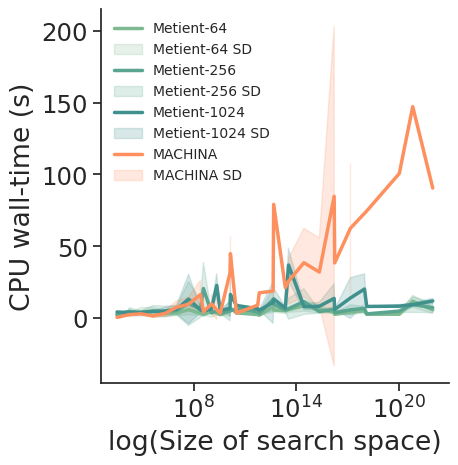

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

methods = ["Metient-64", "Metient-256", "Metient-1024", "MACHINA"]

colors = sns.color_palette("crest")
colors = colors[:len(methods)-1]
colors.append((0.99609375, 0.56640625, 0.37109375))
print(colors)


sns.set(style='ticks', rc={'axes.labelsize': 18, 'xtick.labelsize': 12, 'ytick.labelsize': 15,  "axes.linewidth":2})
sns.set_palette(sns.color_palette(colors))
    
fig = plt.figure(figsize=(2, 2), dpi=200)
with sns.plotting_context("notebook", font_scale=1.6):

    g = sns.relplot(
        data=timing_df, x="Size of search space", y="CPU wall-time (s)",
        dashes=False, linewidth=2.5,
        hue="Method", kind="line",ci='sd',style="Method",  legend=False,
    )


    (g.set_axis_labels("log(Size of search space)", "CPU wall-time (s)")
      .set_titles("boop")
      .tight_layout(w_pad=0))

    #     g = sns.scatterplot(
    #         data=timing_df, x="Size of Search Space", y="CPU Wall-time (s)",
    #         hue="Method",legend=False,
    #     )
    #     g.spines['top'].set_visible(False)
    #     g.spines['right'].set_visible(False)

    labels = []
    for i,method in enumerate(methods):
        labels.append(method)
        labels.append(f"{method} SD")
    print(labels)

    plt.xscale("log")
    #plt.yscale("log")

    print(plt.ylim())

    #plt.xlim(0, 30)
    plt.legend(title='', loc='upper left', fontsize=15, labels=labels, prop={'size': 10}, frameon=False)
    plt.show()

fig = g.fig
fig.savefig(os.path.join(repo_dir, "test/output_plots", f"timing_benchmarks_search_space_{PARAMS}_{DATE}.svg"), dpi=300) 


In [10]:
timing_df[(timing_df['Method']=='Metient-1024')&(timing_df['CPU wall-time (s)']<10)]

,Sites,Mig type,Seed,Number of tree nodes,Size of search space,CPU wall-time (s),Method
4,m5,mS,0,13,244140625,4.665015,Metient-1024
5,m5,mS,0,13,244140625,3.760341,Metient-1024
11,m5,mS,7,9,390625,4.689780,Metient-1024
12,m5,mS,7,9,390625,3.707241,Metient-1024
20,m5,mS,4,12,48828125,4.076252,Metient-1024
...,...,...,...,...,...,...,...
5014,m8,R,157,21,672749994932560009201,8.988264,Metient-1024
5015,m8,R,157,21,672749994932560009201,8.208367,Metient-1024
5016,m8,R,157,21,672749994932560009201,8.476905,Metient-1024
5017,m8,R,157,21,672749994932560009201,9.194381,Metient-1024


In [ ]:
timing_df[timing_df["CPU wall-time (s)"]==221.1873294705]

,Sites,Mig type,Seed,Number of tree nodes,Size of search space,CPU wall-time (s),Method
2429,m8,M,243,18,16677181699666569,221.187329,MACHINA


In [ ]:
met_mode = 'Metient-64'
# Pivot the dataframe
pivot_df = timing_df.pivot_table(index=['Sites', 'Mig type', 'Seed'], columns='Method', values='CPU wall-time (s)')

# Filter for combinations where Metient-64 is lower than MACHINA
filtered_df = pivot_df[pivot_df[met_mode] < pivot_df['MACHINA']]

# Calculate percent decrease
filtered_df['percent_decrease'] = (filtered_df['MACHINA'] - filtered_df[met_mode]) / filtered_df['MACHINA'] * 100

# Find the combination with the largest percent decrease
max_decrease_row = filtered_df['percent_decrease'].idxmax()
max_decrease_value = filtered_df['percent_decrease'].max()

print("Combination with the largest percent decrease where Metient-64 is lower:")
print("Sites:", max_decrease_row[0])
print("Mig type:", max_decrease_row[1])
print("Seed:", max_decrease_row[2])
print("Percent decrease:", max_decrease_value)

Combination with the largest percent decrease where Metient-64 is lower:
Sites: m8
Mig type: M
Seed: 243
Percent decrease: 97.50162486858437


/scratch/lsftmp/8945303.tmpdir/ipykernel_306312/3135945944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['percent_decrease'] = (filtered_df['MACHINA'] - filtered_df[met_mode]) / filtered_df['MACHINA'] * 100
